In [22]:
# !pip install hurst
# !pip install arch
# !pip install bspline

In [23]:
import sys
!{sys.executable} --version
# !pip install bspline

import os
import math
from math import log
from datetime import datetime, timedelta

# import pickle
import numpy as np
from hurst import compute_Hc
from arch import arch_model
from IPython.display import display
import matplotlib.pyplot as plt

import pandas as pd
import yfinance as yf
from yahoofinancials import YahooFinancials
from IPython.display import display
from itertools import pairwise

%matplotlib inline

# import function libraries for calculating value at risk and computing backtesting statistics

from quantile_functions import *
from VaR_backtest_tests import *

# prices = pickle.load(open('stock_prices.pkl','rb'))

# # convert from prices to returns
# returns = dict()
# for k in list(prices.keys()):
#     returns[k] = get_stock_log_returns(prices[k])

Python 3.11.5


# download price history

In [24]:
companies, tickers = ['Meta'],['META']
companies, tickers = ['Amgen'],['AMGN']
# companies, tickers = ['Proctor & Gamble'],['PG']

tickers_df = yf.download(tickers, 
                      start='2017-01-01', 
                      end='2026-01-30', 
                      progress=False, auto_adjust=True)
display(tickers_df.head())
display(tickers_df.tail())

Price,Close,High,Low,Open,Volume
Ticker,AMGN,AMGN,AMGN,AMGN,AMGN
Date,,,,,
2017-01-03,114.922516,115.128378,112.170108,112.734318,3640900
2017-01-04,116.554115,117.202193,115.715439,115.959413,3945900
2017-01-05,116.637962,116.958185,115.517176,116.439732,3441700
2017-01-06,119.535240,122.752735,119.451371,121.898807,9899300
2017-01-09,121.105881,121.189750,119.420896,119.710615,4247700


Price,Close,High,Low,Open,Volume
Ticker,AMGN,AMGN,AMGN,AMGN,AMGN
Date,,,,,
2026-01-23,344.750000,349.230011,341.820007,346.179993,2024900
2026-01-26,349.690002,350.429993,343.619995,344.700012,3116100
2026-01-27,351.320007,353.250000,346.929993,348.570007,3269600
2026-01-28,342.220001,351.950012,340.000000,349.000000,2347800
2026-01-29,342.940002,347.269989,338.750000,341.660004,3153100


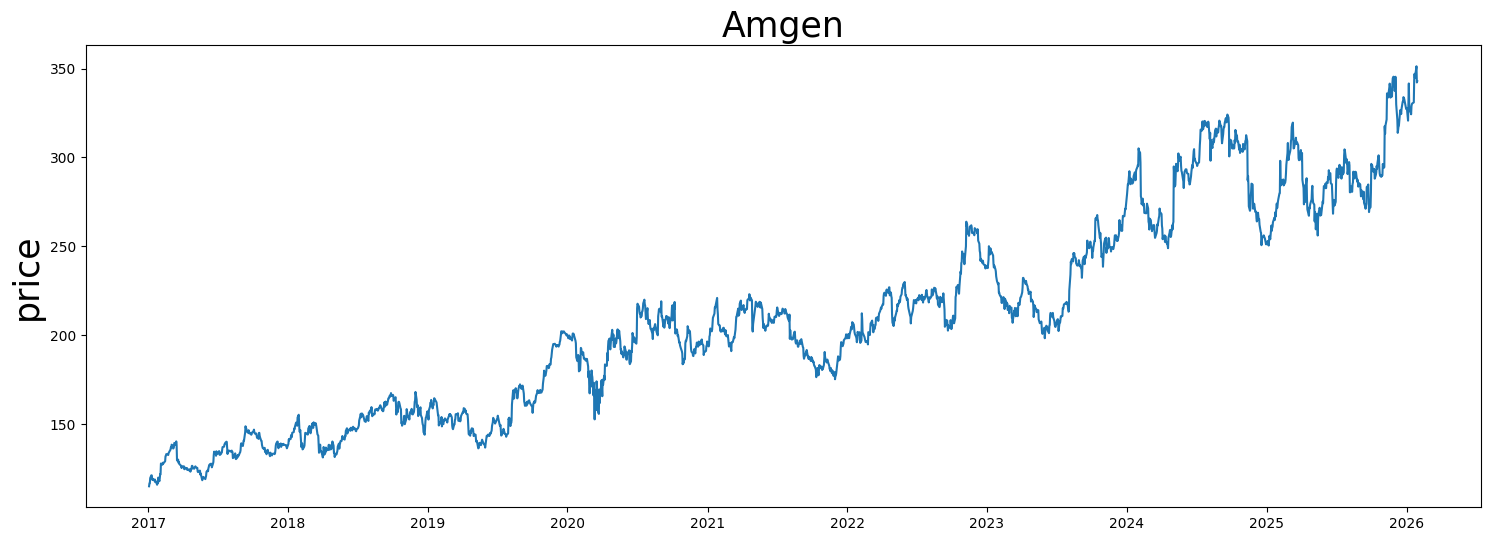

In [25]:
company = companies[0]
ticker = tickers[0]

prices = {ticker: tickers_df['Close']}

plt.figure(figsize=(18,6))
plt.plot(prices[ticker])
plt.title(company, fontsize=25)
plt.ylabel('price', fontsize=25)             
plt.show()

# plot daily returns

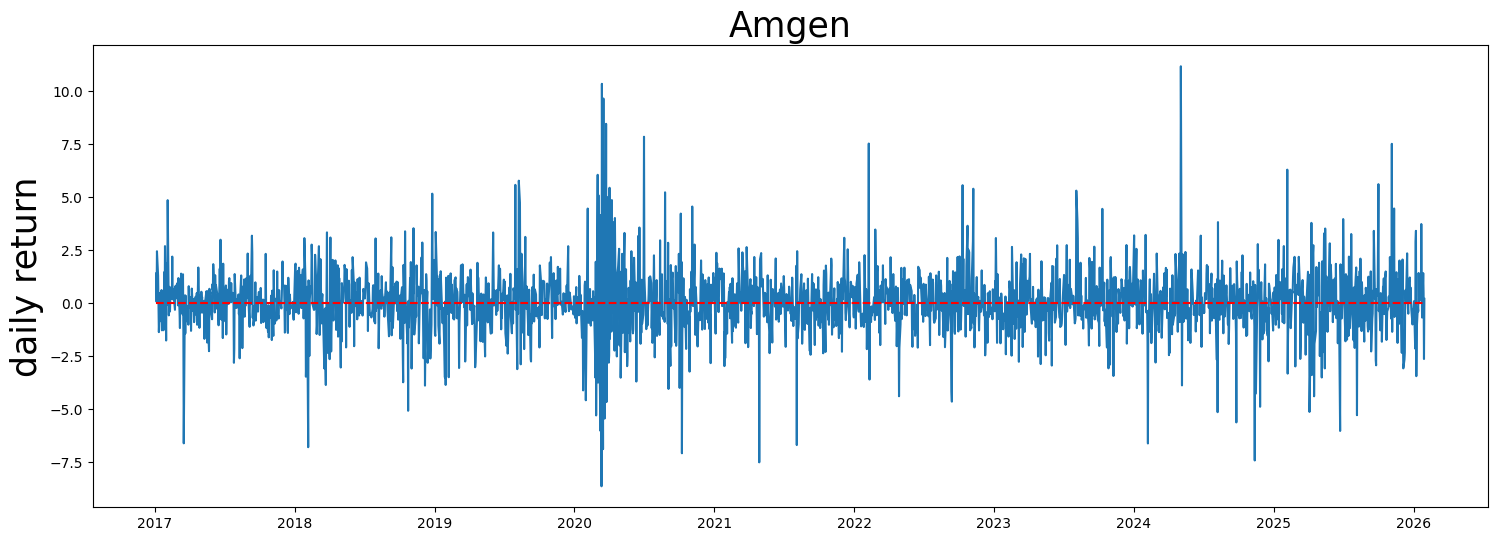

In [26]:
returns = {ticker: tickers_df[('Close',ticker)].apply(log).diff()[1:]}
train = returns[ticker] * 100
train2 = train * train

plt.figure(figsize=(18,6))
plt.plot(train)
plt.title(company, fontsize=25)
plt.plot([train.index[0], train.index[-1]], [0,0], '--',color='red')
plt.ylabel('daily return', fontsize=25) 
plt.show()

# Historical distribution of returns

In [27]:
p = 0.05

nonparametric 95.0% Value at Risk = -2.3331


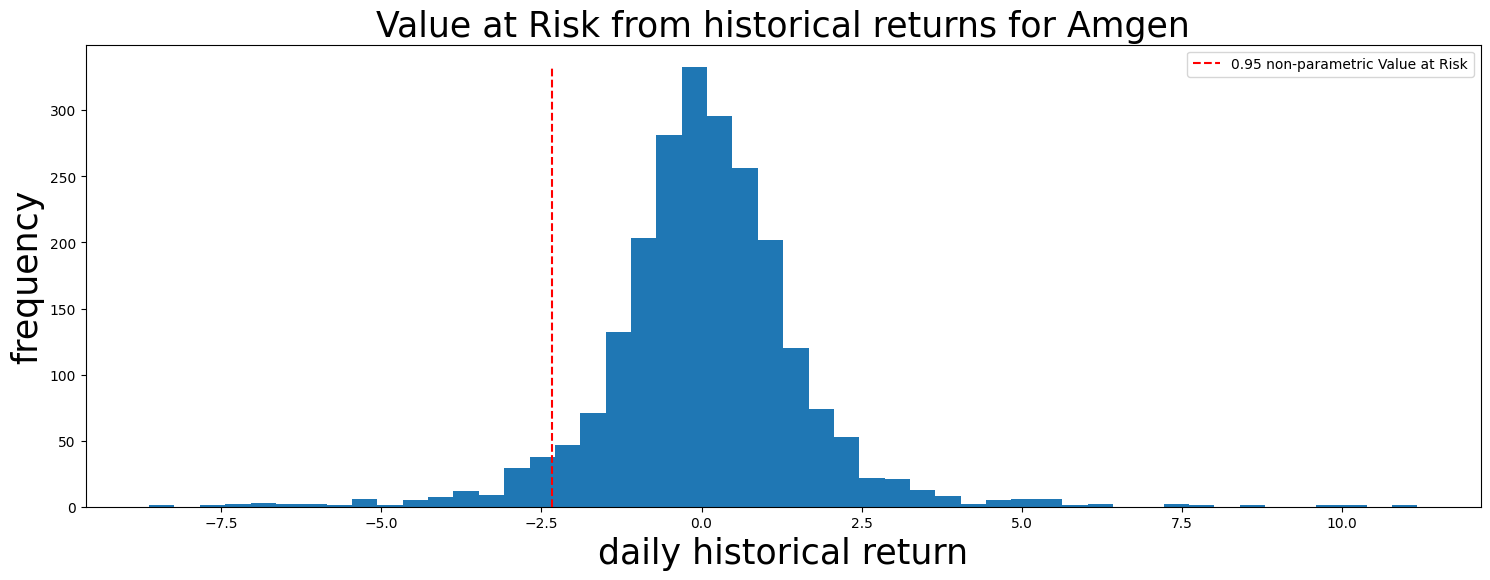

In [28]:
plt.figure(figsize=(18,6))
hist = plt.hist(train,50)
plt.title(f'Value at Risk from historical returns for {company}', fontsize=25)
plt.xlabel('daily historical return', fontsize=25)
plt.ylabel('frequency', fontsize=25)

VaRcutoff = np.quantile(train, p)
print(f"nonparametric {100 - 100 * p}% Value at Risk = {VaRcutoff:0.4f}")
plt.plot([VaRcutoff,VaRcutoff],[0, max(hist[0])], '--',color='red', label=f"{1-p} non-parametric Value at Risk")
plt.legend()
plt.show()

# VaR assuming a Gaussian distribution

daily return mean = 0.047952 and standard deviation = 1.553441

cutoff = -1.6449 * 1.5534 at probability 0.05

parametric 95.0% Value at Risk = -2.5552


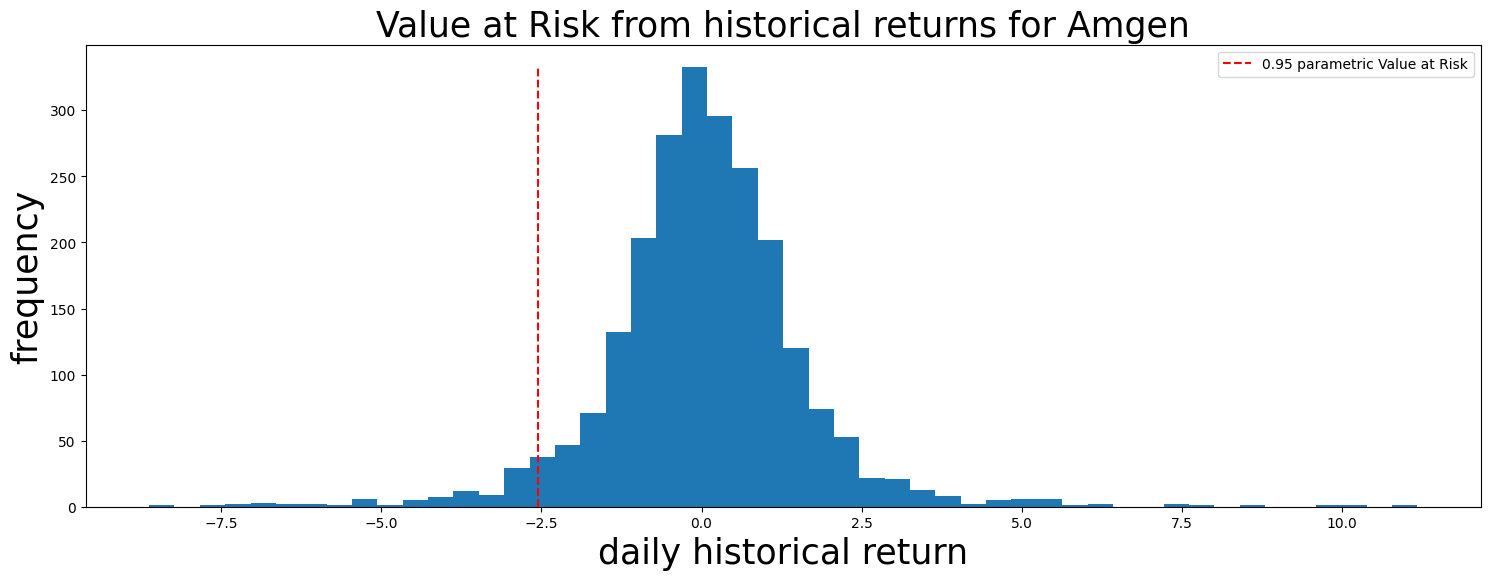

In [29]:
from scipy.stats import norm

mu, sigma = np.mean(train), np.std(train)
print(f"daily return mean = {mu:0.6f} and standard deviation = {sigma:0.6f}")

plt.figure(figsize=(18,6))
hist = plt.hist(train,50)
plt.title(f'Value at Risk from historical returns for {company}', fontsize=25)
plt.xlabel('daily historical return', fontsize=25)
plt.ylabel('frequency', fontsize=25)

VaRcutoff = norm.ppf(p) * sigma
print(f"\ncutoff = {norm.ppf(p):0.4f} * {sigma:0.4f} at probability {p}")
print(f"\nparametric {100 - 100 * p}% Value at Risk = {VaRcutoff:0.4f}")
plt.plot([VaRcutoff,VaRcutoff],[0, max(hist[0])], '--',color='red', label=f"{1-p} parametric Value at Risk")
plt.legend()
plt.show()

# MA: Fit interval moving average value at risk
## note abrupt drop and rise in VaR in late 2018

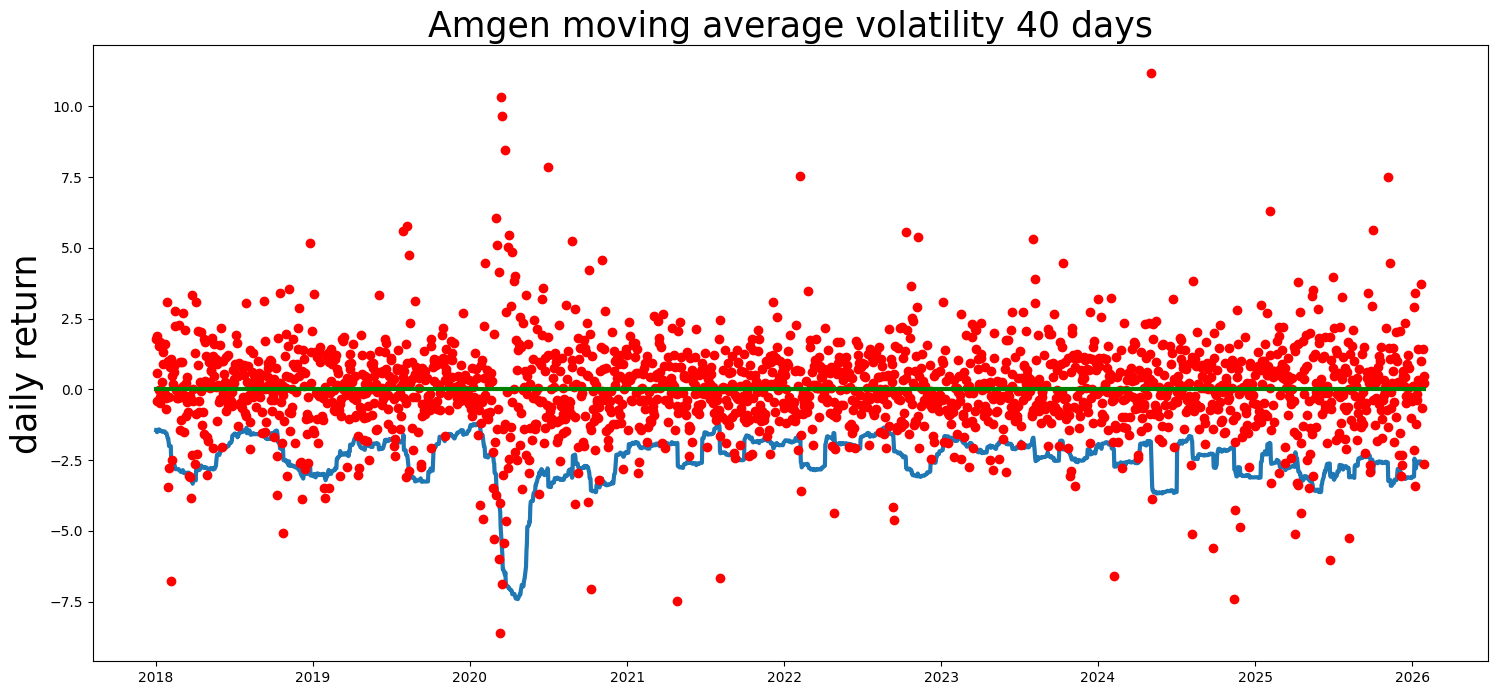

In [30]:
history_n = 40  # length of window for calculating historical volatility
MAVaR40 = [-1.645 * np.sqrt(np.mean(train2[i:i+history_n])) for i,_ in enumerate(train2[:-history_n])]

MAVaR40_df = pd.DataFrame(MAVaR40[:], index=pd.DataFrame(train).index[40:], columns=['VaR'])
plt.figure(figsize=(18,8))
start_date = '2018-01-01'
plt.plot(MAVaR40_df[start_date:]['VaR'],linewidth=3)
plt.plot(pd.DataFrame(train[start_date:]), 'ro')
plt.plot(pd.DataFrame([0,0],index=MAVaR40_df[start_date:].index[[0,-1]]), 'g-',linewidth=3)
plt.title(f"{company} moving average volatility {history_n} days", fontsize=25)
plt.ylabel('daily return', fontsize=25)
plt.show()

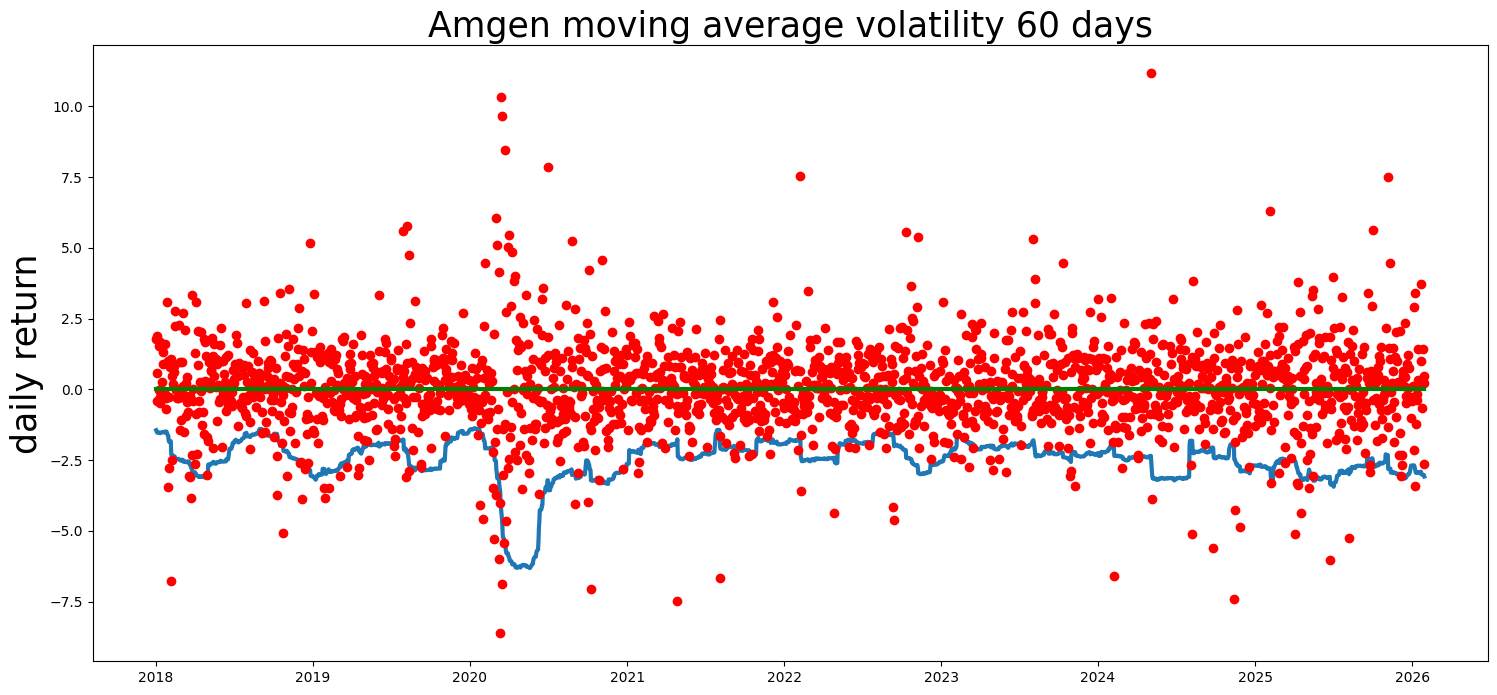

In [31]:
history_n = 60  # length of window for calculating historical volatility
MAVaR60 = [-1.645 * np.sqrt(np.mean(train2[i:i+history_n])) for i,_ in enumerate(train2[:-history_n])]

MAVaR60_df = pd.DataFrame(MAVaR60[:], index=pd.DataFrame(train).index[history_n:], columns=['VaR'])

plt.figure(figsize=(18,8))
start_date = '2018-01-01'
plt.plot(MAVaR60_df[start_date:]['VaR'],linewidth=3)
plt.plot(pd.DataFrame(train[start_date:]), 'ro')
plt.plot(pd.DataFrame([0,0],index=MAVaR60_df[start_date:].index[[0,-1]]), 'g-',linewidth=3)
plt.title(f"{company} moving average volatility {history_n} days", fontsize=25)
plt.ylabel('daily return', fontsize=25)
plt.show()

# Comparison of 40 vs 60 day Moving Average

In [32]:
MAV = pd.concat([MAVaR40_df, MAVaR40_df.diff(), MAVaR60_df, MAVaR60_df.diff()], axis=1)
MAV.columns = ['40 day MA','diff 40 day MA','60 day MA','diff 60 day MA']
display(MAV.tail())

,40 day MA,diff 40 day MA,60 day MA,diff 60 day MA
Date,,,,
2026-01-23,-2.681020,0.003862,-3.012951,-0.006445
2026-01-26,-2.674951,0.006069,-3.015999,-0.003048
2026-01-27,-2.648997,0.025954,-3.030339,-0.014340
2026-01-28,-2.638733,0.010264,-3.031859,-0.001520
2026-01-29,-2.724764,-0.086032,-3.082614,-0.050755


In [33]:
top_5_diffs = MAV['diff 40 day MA'].nsmallest(5)
print("diff 40 day MA days with the largest increase in VaR")
print(top_5_diffs)

top_5_diffs = MAV['diff 60 day MA'].nsmallest(5)
print("\ndiff 60 day MA days with the largest increase in VaR")
print(top_5_diffs)


diff 40 day MA days with the largest increase in VaR
Date
2024-05-06   -1.576231
2022-02-09   -0.888153
2021-08-05   -0.856181
2021-04-29   -0.819672
2024-11-13   -0.747048
Name: diff 40 day MA, dtype: float64

diff 60 day MA days with the largest increase in VaR
Date
2024-05-06   -0.680656
2021-04-29   -0.609837
2022-02-09   -0.599678
2021-08-05   -0.571414
2020-03-16   -0.521948
Name: diff 60 day MA, dtype: float64


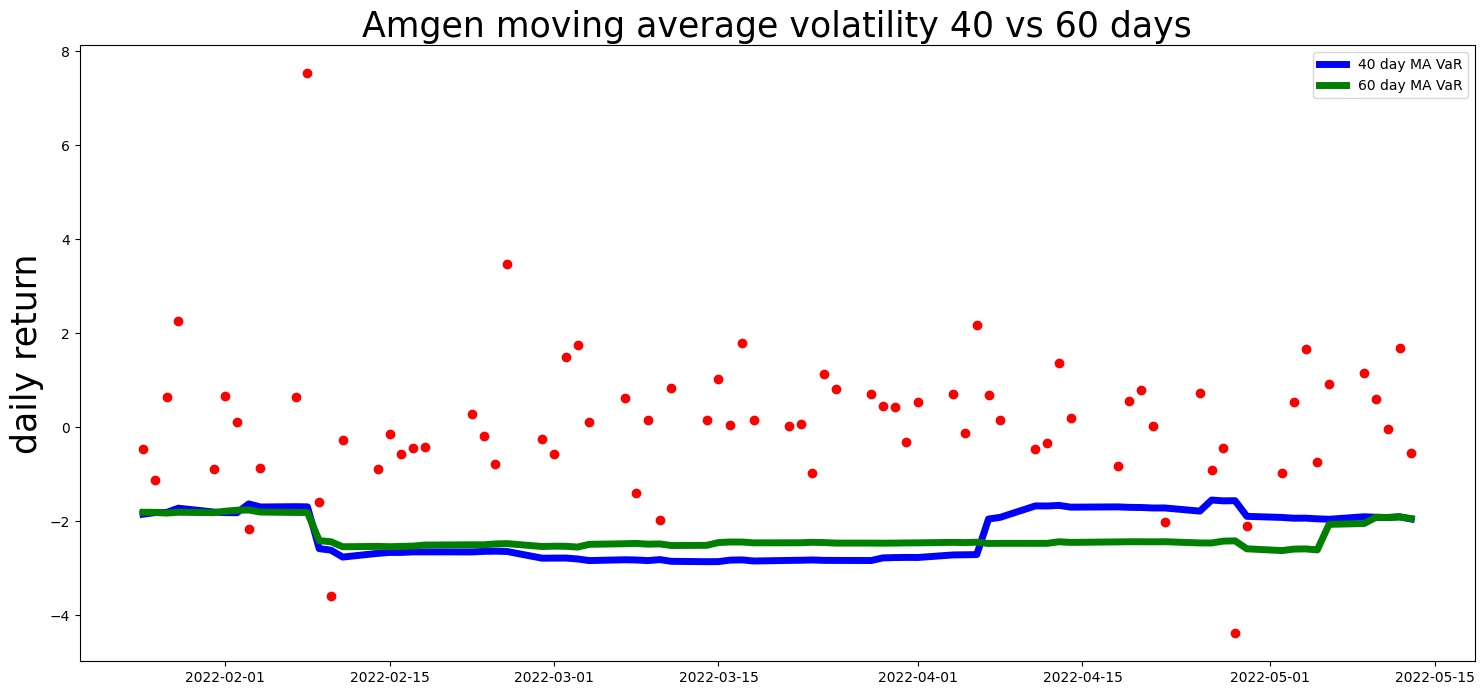

In [34]:
plt.figure(figsize=(18,8))
start_date = '2022-02-04'
_start_date = datetime.datetime.strptime(start_date, '%Y-%m-%d')
start_date = str(_start_date + timedelta(days=-10))[:10]
end_date = str(_start_date + timedelta(days=100))[:10]

plt.plot(pd.DataFrame(train[start_date:end_date]), 'ro')
plt.plot(MAV['40 day MA'][start_date:end_date], linewidth=5, color='blue', label='40 day MA VaR')
plt.plot(MAV['60 day MA'][start_date:end_date], linewidth=5, color='green', label='60 day MA VaR')

plt.title(f"{company} moving average volatility 40 vs 60 days", fontsize=25)
plt.ylabel('daily return', fontsize=25)
plt.legend()
plt.show()

# EWMA: exponential weighted moving average volatiity

$$\sigma^2_n = (1 - \lambda) u^2_{n-1} + \lambda \sigma^2_{n-1}$$ 

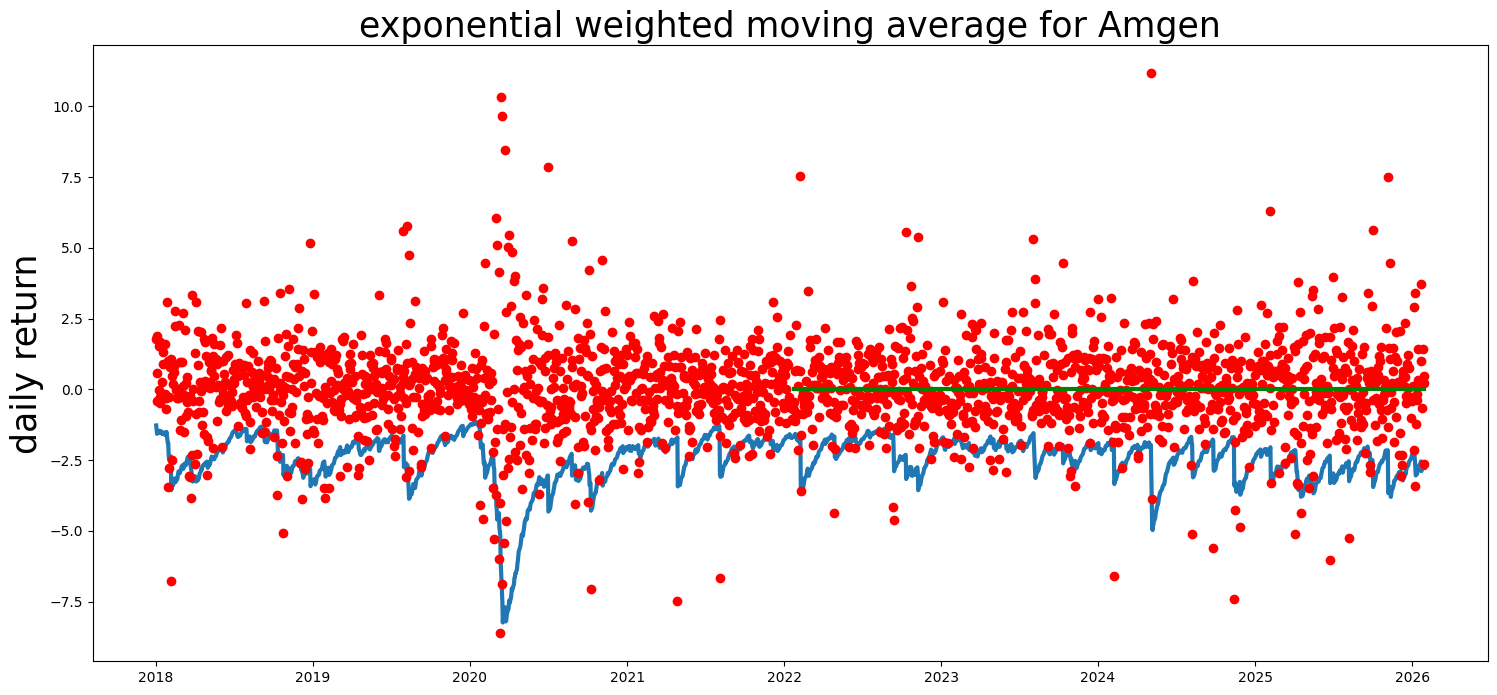

In [35]:
train2 = train * train

wt = .94
vol = train2[0]
vol_history = [0,vol]  # move everything forward one day
for v in train2[1:]:
    vol = wt * vol + (1 - wt) * v
    vol_history.append(vol)
    
vol_df = pd.DataFrame(vol_history[:-1], index=train.index, columns=['vol'])
vol_df['EWMA'] = [-1.64 * math.sqrt(x) for x in vol_df['vol']]

plt.figure(figsize=(18,8))
plt.plot(vol_df['2018-01-01':]['EWMA'], linewidth=3)
plt.plot(pd.DataFrame(train['2018-01-01':]), 'ro')
plt.plot(pd.DataFrame([0,0],index=MAVaR60_df[start_date:].index[[0,-1]]), 'g-',linewidth=3)
plt.title(f'exponential weighted moving average for {company}', fontsize=25)
plt.ylabel('daily return', fontsize=25)
plt.show()

# GARCH(1,1) model

$$\sigma^2_n = \omega + \alpha u^2_{n-1} + \beta \sigma^2_{n-1}$$

Iteration:      1,   Func. Count:      5,   Neg. LLF: 3880.980439762275
Iteration:      2,   Func. Count:     13,   Neg. LLF: 1279.4154405805075
Iteration:      3,   Func. Count:     19,   Neg. LLF: 1299.6941324924835
Iteration:      4,   Func. Count:     25,   Neg. LLF: 1254.5916879796414
Iteration:      5,   Func. Count:     29,   Neg. LLF: 1254.5888968777513
Iteration:      6,   Func. Count:     33,   Neg. LLF: 1254.5888940009359
Iteration:      7,   Func. Count:     36,   Neg. LLF: 1254.5888940009497
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1254.5888940009359
            Iterations: 7
            Function evaluations: 36
            Gradient evaluations: 7
                       Zero Mean - GARCH Model Results                        
Dep. Variable:      ('Close', 'AMGN')   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-L

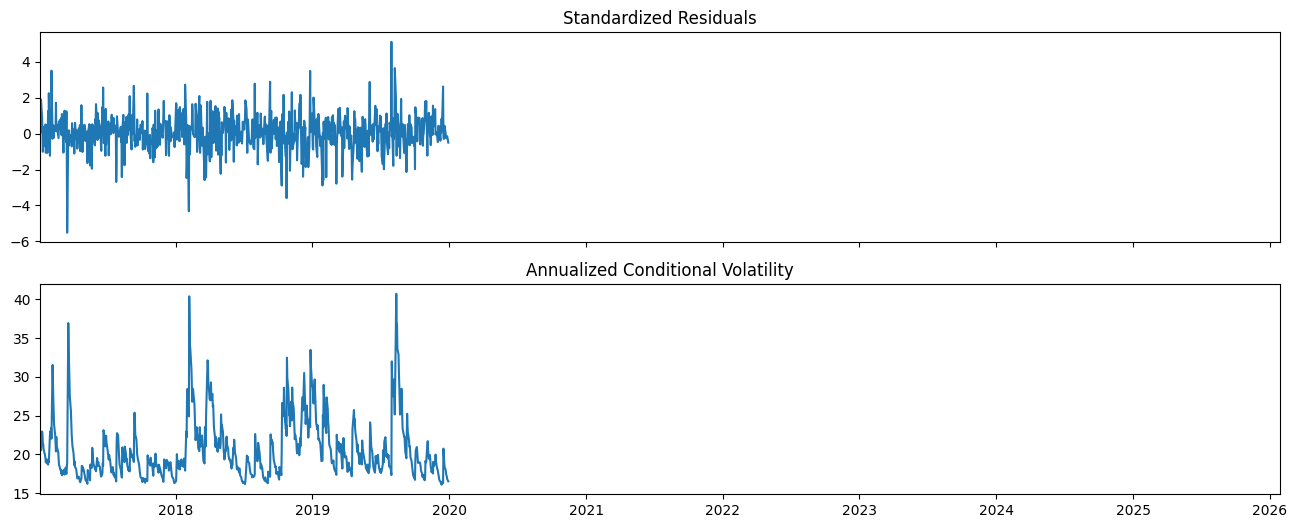

In [36]:
train = returns[ticker] * 100

model = arch_model(train, mean='Zero', vol='GARCH', p=1, q=1)
res = model.fit(last_obs='2019-12-31')
print(res.summary())
plt.rc("figure", figsize=(16, 6))
fig = res.plot(annualize='D')
print(res.params, res.tvalues, res._params, res._names)

### GARCH parameters

In [37]:
display(pd.DataFrame(res.params))
persistence = res.params['alpha[1]'] + res.params['beta[1]']
print(f"\npersistence = {persistence:0.3} (speed of mean reversion see Jorion Fig 9-6 page 229)")
print(f"unconditional variance = {res.params['omega'] / ( 1 - persistence): 0.3}")

,params
omega,0.182014
alpha[1],0.093649
beta[1],0.803421



persistence = 0.897 (speed of mean reversion see Jorion Fig 9-6 page 229)
unconditional variance =  1.77


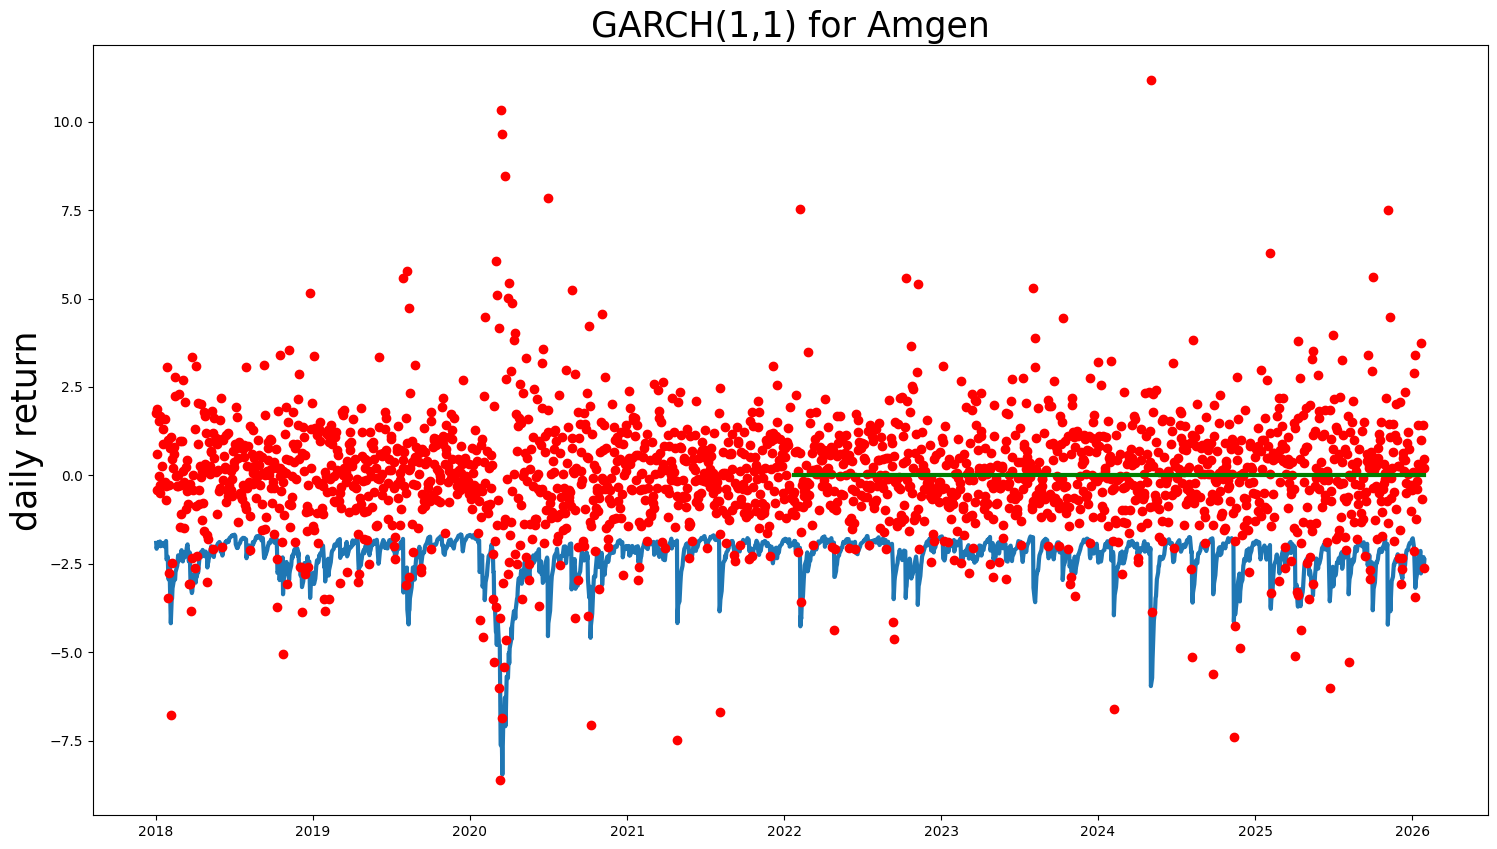

In [38]:
from arch.__future__ import reindexing

forecasts = res.forecast(start='2018-01-01') # .variance['h.1']
cond_mean = forecasts.mean['2018-01-01':]
cond_var = forecasts.variance['2018-01-01':]
q = model.distribution.ppf([p]) 
value_at_risk = pd.DataFrame([-x[0] for x in -cond_mean.values - np.sqrt(cond_var).values * q], 
                             index=train['2018-01-01':].index)
plt.figure(figsize=(18,10))
plt.plot(value_at_risk, linewidth=3)
plt.plot(train['2018-01-01':], 'ro')
plt.plot(pd.DataFrame([0,0],index=MAVaR60_df[start_date:].index[[0,-1]]), 'g-',linewidth=3)
plt.title(f'GARCH(1,1) for {company}', fontsize=25)
plt.ylabel('daily return', fontsize=25)
plt.show()

# Ljung-Box

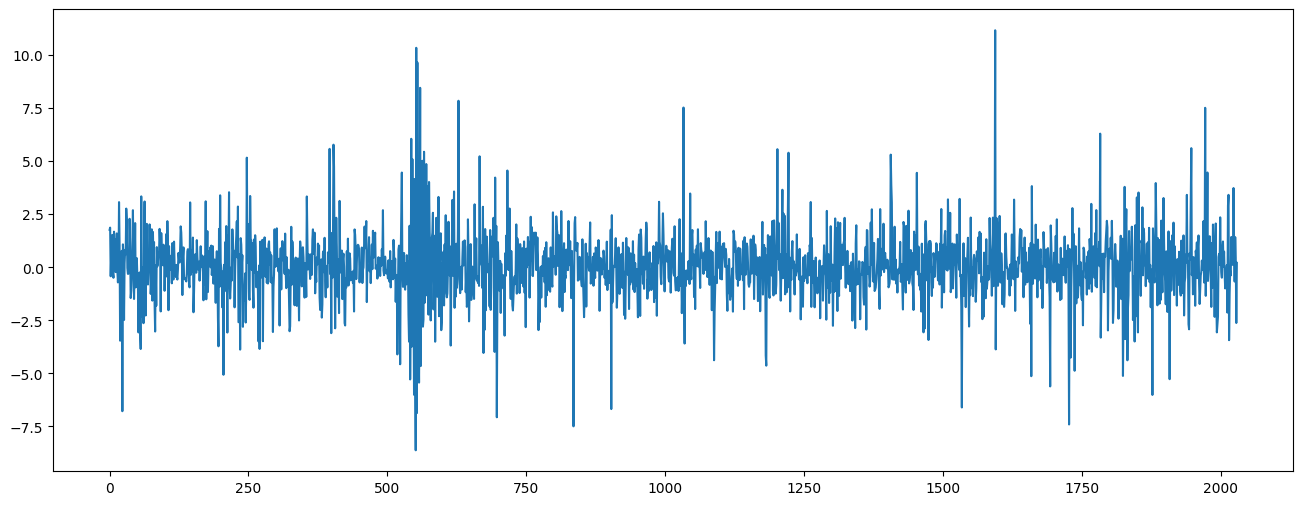

In [39]:
plt.plot(train['2018-01-01':].tolist())
plt.show()

      lb_stat     lb_pvalue
1   12.360855  4.384298e-04
2   13.637780  1.092933e-03
3   15.614110  1.360410e-03
4   15.614687  3.582273e-03
5   15.816958  7.386570e-03
6   30.689684  2.905185e-05
7   48.242142  3.192834e-08
8   57.537451  1.414267e-09
9   80.605624  1.224997e-13
10  81.991668  2.041137e-13


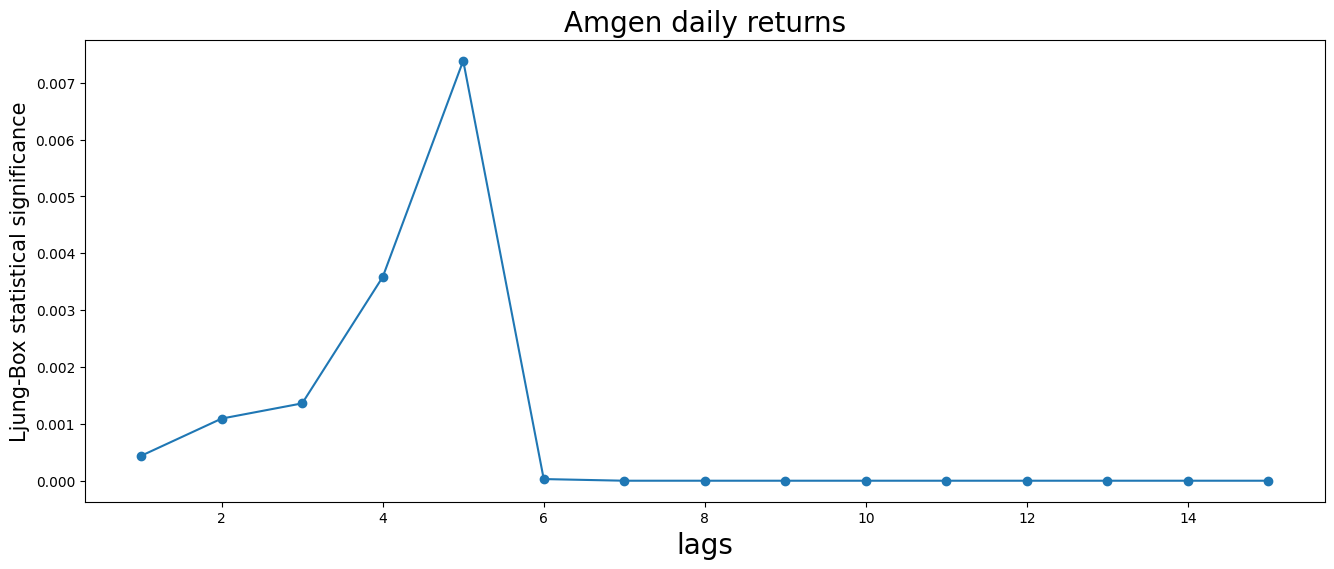

      lb_stat     lb_pvalue
1    0.164854  6.847265e-01
2    5.304777  7.048267e-02
3    6.060866  1.086862e-01
4   11.195199  2.445566e-02
5   11.947948  3.550802e-02
6   13.723922  3.287684e-02
7   35.050704  1.094168e-05
8   35.052669  2.615422e-05
9   52.289023  3.985595e-08
10  53.074433  7.212682e-08


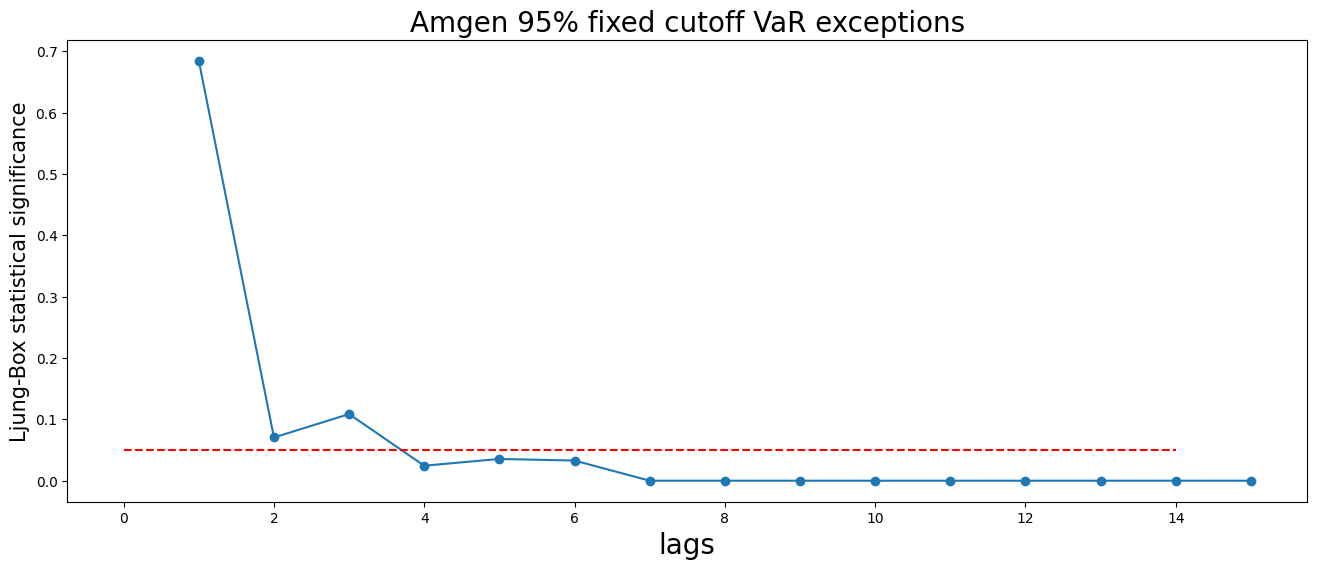

In [40]:
import numpy as np
from statsmodels.stats.diagnostic import acorr_ljungbox

x = train['2018-01-01':].tolist()
x = np.asarray(x)

lags = 15
lb = acorr_ljungbox(x, lags=lags, return_df=True)

print(lb[:10])
plt.plot(lb['lb_pvalue'],'o-')
plt.title(f"{company} daily returns", fontsize=20)
plt.ylabel("Ljung-Box statistical significance", fontsize=15)
plt.xlabel("lags", fontsize=20)
plt.show()

# Choose threshold (e.g. 95th percentile)
u = np.quantile(x, 0.95)

# Event indicator
E = (x > u).astype(int)

lb = acorr_ljungbox(E, lags=lags, return_df=True)

print(lb[:10])
plt.plot(lb['lb_pvalue'],'o-')
plt.plot([0.05] * len(lb['lb_pvalue']), '--', color='red')
plt.title(f"{company} 95% fixed cutoff VaR exceptions", fontsize=20)
plt.ylabel("Ljung-Box statistical significance", fontsize=15)
plt.xlabel("lags", fontsize=20)
plt.show()

[((0, 0), 1838), ((0, 1), 92), ((1, 0), 92), ((1, 1), 7)]


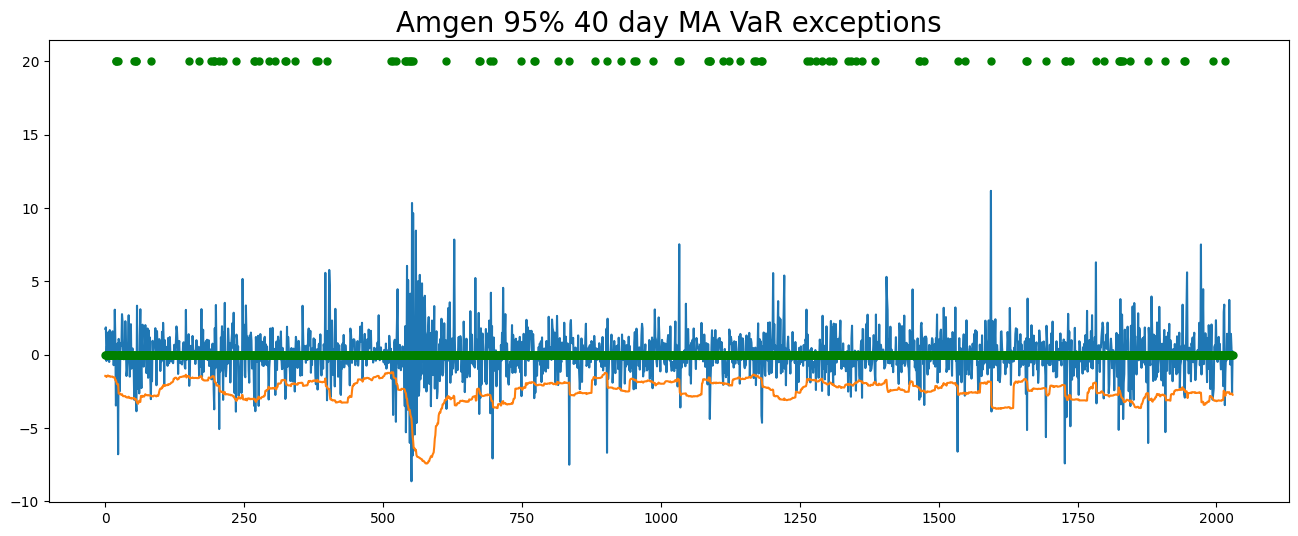

      lb_stat  lb_pvalue
1    1.079024   0.298916
2    5.061840   0.079586
3    6.137198   0.105123
4   12.255657   0.015548
5   13.327352   0.020497
6   14.107380   0.028459
7   14.112923   0.049209
8   14.277994   0.074801
9   14.283208   0.112602
10  14.586747   0.147870


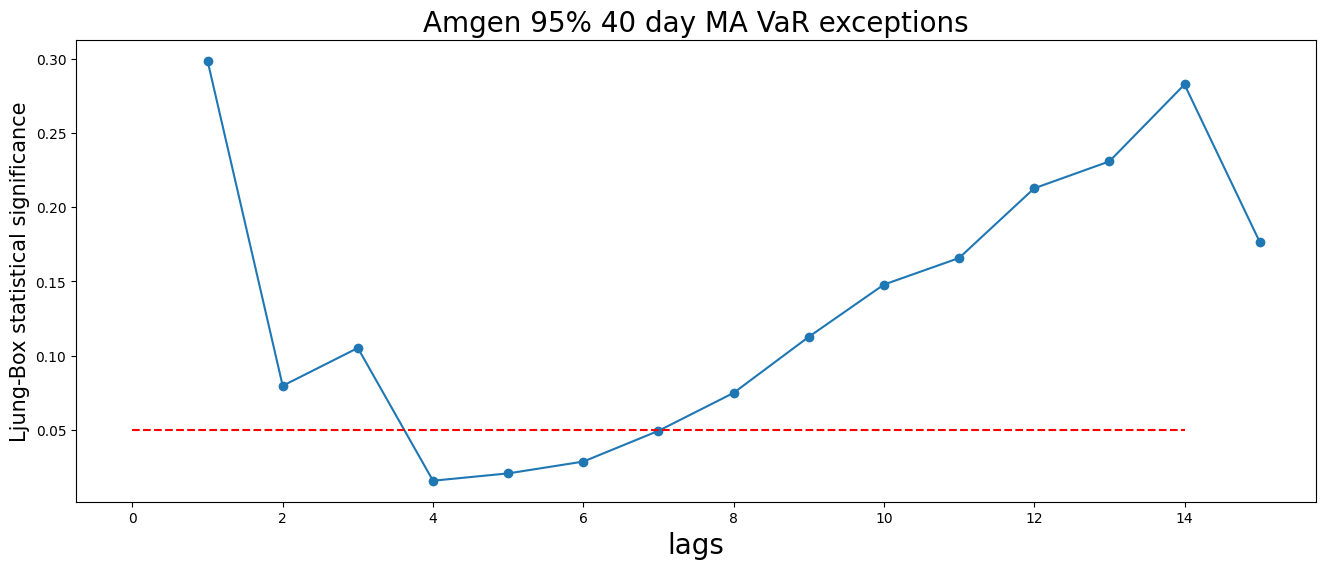

In [41]:

value_at_risk = [-x[0] for x in -cond_mean.values - np.sqrt(cond_var).values * q]

vol_df = pd.DataFrame(vol_history[:-1], index=train.index, columns=['vol'])
value_at_risk =  [-1.64 * math.sqrt(x) for x in vol_df['vol']][-2030:]

# value_at_risk = MAVaR60[-2030:]
value_at_risk = MAVaR40[-2030:]


x = train['2018-01-01':].tolist()
x = np.asarray(x)

u = value_at_risk

# Event indicator
E = 1 - (x > u).astype(int)

print(Counter([(a,b) for a,b in pairwise(E)]).most_common() )

plt.plot(x)
plt.plot(u)
plt.plot(E*20, 'go', ms=5)
plt.title(f"{company} 95% 40 day MA VaR exceptions", fontsize=20)
plt.show()

lb = acorr_ljungbox(E, lags=lags, return_df=True)

print(lb[:10])
plt.plot(lb['lb_pvalue'], 'o-')
plt.plot([0.05] * len(lb['lb_pvalue']), '--', color='red')
plt.title(f"{company} 95% 40 day MA VaR exceptions", fontsize=20)
plt.ylabel("Ljung-Box statistical significance", fontsize=15)
plt.xlabel("lags", fontsize=20)
plt.show()

# Ljung-Box code

In [42]:
def compute_Ljung_Box(E):
    h = 10
    alpha = sum(E)/len(E)
    n = len(E)
    I_tilda = E - alpha

    den = sum([x * x for x in I_tilda])

    Q, Q_k = [], []
    for k in range(1,h+1):
        num = sum([x * y for x,y in zip(I_tilda[k:], I_tilda[:-k])])
        p_k = num / den
        Q_k.append(pow(p_k, 2) / (n - k))
        Q.append(n * (n + 2) * sum(Q_k))
    
    return Q

Q = compute_Ljung_Box(E)
print(*zip(range(len(Q)),Q), sep='\n')


(0, 1.0790244489950256)
(1, 5.061840143414509)
(2, 6.137198240168134)
(3, 12.255657093802936)
(4, 13.32735199051493)
(5, 14.107379966369432)
(6, 14.11292329775515)
(7, 14.277994368157751)
(8, 14.283208420245693)
(9, 14.586746615319079)
